# RQ1 Notebook — Cross-Modal Fusion Performance

Standalone Kaggle notebook for **RQ1**. Outputs are saved as PDF figures and CSV tables under `/kaggle/working/outputs/`.

In [1]:

import os, zipfile, warnings, random, math
from pathlib import Path
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
try:
    from xgboost import XGBRegressor
    HAS_XGB=True
except Exception:
    HAS_XGB=False
SEED=42; np.random.seed(SEED); random.seed(SEED)
OUT=Path('/kaggle/working/outputs') if Path('/kaggle/working').exists() else Path('outputs')
FIG=OUT/'figures'; TAB=OUT/'tables'
for d in [OUT,FIG,TAB]: d.mkdir(parents=True, exist_ok=True)
print('Output folder:', OUT)

def RMSE(y,p): return float(np.sqrt(mean_squared_error(y,p)))
def WAPE(y,p): return float(100*np.sum(np.abs(np.asarray(y)-np.asarray(p)))/max(np.sum(np.abs(y)),1e-9))
def PEAK_MAE(y,p):
    y=np.asarray(y); p=np.asarray(p); m=y>=np.quantile(y,.9)
    return float(mean_absolute_error(y[m],p[m])) if m.sum() else np.nan
def metrics(y,p): return {'RMSE':RMSE(y,p),'MAE':float(mean_absolute_error(y,p)),'WAPE (%)':WAPE(y,p),'Peak-MAE':PEAK_MAE(y,p)}
def savefig(name):
    plt.tight_layout(); path=FIG/f'{name}.pdf'; plt.savefig(path,bbox_inches='tight'); plt.show(); print('Saved:',path)
def savetab(df,name):
    path=TAB/f'{name}.csv'; df.to_csv(path,index=False); print('Saved:',path); return df

def find_hour_csv():
    for root in [Path('/kaggle/input'),Path('/kaggle/working'),Path.cwd(),Path('/mnt/data')]:
        if root.exists():
            hits=list(root.rglob('hour.csv'))
            if hits: return hits[0]
    return None

def load_data():
    p=find_hour_csv()
    if p is not None:
        print('Using:',p); return pd.read_csv(p)
    print('hour.csv not found. Trying UCI download; if blocked, synthetic data is used only for code testing.')
    try:
        import urllib.request
        z=OUT/'bike.zip'; urllib.request.urlretrieve('https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip', z)
        with zipfile.ZipFile(z) as zz: zz.extractall(OUT/'bike')
        return pd.read_csv(OUT/'bike'/'hour.csv')
    except Exception as e:
        print('Download failed:',e)
        rng=pd.date_range('2011-01-01',periods=24*730,freq='H')
        df=pd.DataFrame({'dteday':rng.date.astype(str),'hr':rng.hour,'weekday':rng.weekday,'mnth':rng.month,'yr':rng.year-rng.year.min()})
        df['season']=((rng.month%12)//3+1); df['holiday']=((rng.dayofyear%91)==0).astype(int); df['workingday']=((rng.weekday<5)&(df.holiday==0)).astype(int)
        df['weathersit']=np.random.choice([1,2,3],len(df),p=[.65,.25,.1]); df['temp']=np.clip(.45+.25*np.sin(2*np.pi*rng.dayofyear/365)+np.random.normal(0,.07,len(df)),0,1)
        df['atemp']=df.temp+np.random.normal(0,.02,len(df)); df['hum']=np.clip(.6+np.random.normal(0,.15,len(df)),0,1); df['windspeed']=np.clip(np.random.gamma(2,.08,len(df)),0,1)
        commute=((rng.hour.isin([7,8,17,18]))&(rng.weekday<5))*80; leisure=((rng.hour.isin(range(11,18)))&(rng.weekday>=5))*50
        df['cnt']=np.maximum(0,35+commute+leisure+30*df.temp-(df.weathersit-1)*15-df.hum*10+np.random.normal(0,12,len(df))).astype(int)
        df['casual']=(df.cnt*np.random.uniform(.2,.45,len(df))).astype(int); df['registered']=df.cnt-df.casual; return df

def prep(raw):
    df=raw.copy(); df['datetime']=pd.to_datetime(df.dteday)+pd.to_timedelta(df.hr,unit='h'); df=df.sort_values('datetime').reset_index(drop=True); df['target']=df.cnt.astype(float)
    for col,period in [('hr',24),('weekday',7),('mnth',12)]:
        df[f'{col}_sin']=np.sin(2*np.pi*df[col]/period); df[f'{col}_cos']=np.cos(2*np.pi*df[col]/period)
    for lag in [1,2,3,6,12,24,48,168]: df[f'lag_{lag}']=df.target.shift(lag)
    for w in [3,6,24,168]: df[f'roll_mean_{w}']=df.target.shift(1).rolling(w).mean(); df[f'roll_std_{w}']=df.target.shift(1).rolling(w).std()
    df['is_weekend']=(df.weekday>=5).astype(int); df['is_commute']=((df.hr.isin([7,8,9,16,17,18]))&(df.workingday==1)).astype(int); df['is_leisure']=((df.hr.between(10,18))&(df.is_weekend==1)).astype(int)
    df['severe_weather']=((df.weathersit>=3)|(df.hum>.85)|(df.windspeed>df.windspeed.quantile(.9))).astype(int)
    types=['CBD','Residential','University','Tourist','Transit Hub','Mixed-use']; sids=np.arange(1,31); df['station_id']=sids[np.arange(len(df))%30]
    m={sid:types[(sid-1)%len(types)] for sid in sids}; df['neighborhood_type']=df.station_id.map(m)
    desc={'CBD':[.15,.8,.85,.1,.25,.9],'Residential':[.85,.2,.25,.15,.15,.35],'University':[.35,.35,.3,.95,.25,.55],'Tourist':[.2,.45,.35,.2,.95,.65],'Transit Hub':[.3,.55,.5,.2,.35,.95],'Mixed-use':[.5,.55,.45,.45,.45,.6]}
    cols=['residential_density','commercial_density','office_intensity','education_density','tourism_poi_density','transit_access']
    for i,c in enumerate(cols): df[c]=np.clip(df.neighborhood_type.map(lambda t:desc[t][i])+df.station_id.map(lambda sid:((sid*17+i*13)%11-5)/100),0,1)
    return df.dropna().reset_index(drop=True)

def split(df):
    n=len(df); return df.iloc[:int(.7*n)].copy(), df.iloc[int(.7*n):int(.85*n)].copy(), df.iloc[int(.85*n):].copy()
TEMP=['hr','weekday','mnth','season','workingday','hr_sin','hr_cos','weekday_sin','weekday_cos','mnth_sin','mnth_cos','lag_1','lag_2','lag_3','lag_6','lag_12','lag_24','lag_48','lag_168','roll_mean_3','roll_std_3','roll_mean_6','roll_std_6','roll_mean_24','roll_std_24','roll_mean_168','roll_std_168']
WEA=['temp','atemp','hum','windspeed','weathersit','severe_weather']; CAL=['holiday','is_weekend','is_commute','is_leisure','workingday']
NEI_NUM=['residential_density','commercial_density','office_intensity','education_density','tourism_poi_density','transit_access']; NEI_CAT=['neighborhood_type']
def model():
    return XGBRegressor(n_estimators=220,max_depth=4,learning_rate=.06,subsample=.9,colsample_bytree=.9,objective='reg:squarederror',random_state=SEED,n_jobs=2) if HAS_XGB else RandomForestRegressor(n_estimators=220,max_depth=14,random_state=SEED,n_jobs=-1)
def fitpred(train,test,features,name):
    features = list(dict.fromkeys(features))
    Xtr=train[features]; Xte=test[features]; cat=[c for c in features if Xtr[c].dtype=='object']; num=[c for c in features if c not in cat]
    pipe=Pipeline([('prep',ColumnTransformer([('num',StandardScaler(),num),('cat',OneHotEncoder(handle_unknown='ignore'),cat)])),('model',model())])
    pipe.fit(Xtr,train.target); p=np.maximum(0,pipe.predict(Xte)); m=metrics(test.target,p); m['Model']=name; return pipe,p,m
raw=load_data(); df=prep(raw); train,val,test=split(df); train_full=pd.concat([train,val]); print(df.shape)


Output folder: /kaggle/working/outputs
Using: /kaggle/input/datasets/shakelz/hour-dataset/hour.csv
(17211, 53)


## RQ1 — Cross-modal fusion performance

Saved: /kaggle/working/outputs/tables/rq1_table_1_1_overall_quantitative_performance.csv


,Model,RMSE,MAE,WAPE (%),Peak-MAE
5,Full Cross-Modal Fusion,45.903163,29.478214,12.566454,64.508201
2,Temporal + Weather,47.650106,30.919379,13.180817,68.235365
4,Temporal + Neighborhood,49.304893,30.800077,13.129959,59.182098
1,Temporal Only,49.510590,30.792717,13.126822,59.551936
3,Temporal + Calendar,49.987122,31.205316,13.302711,67.150734
0,Historical Average,133.249245,89.316291,38.075205,280.754288


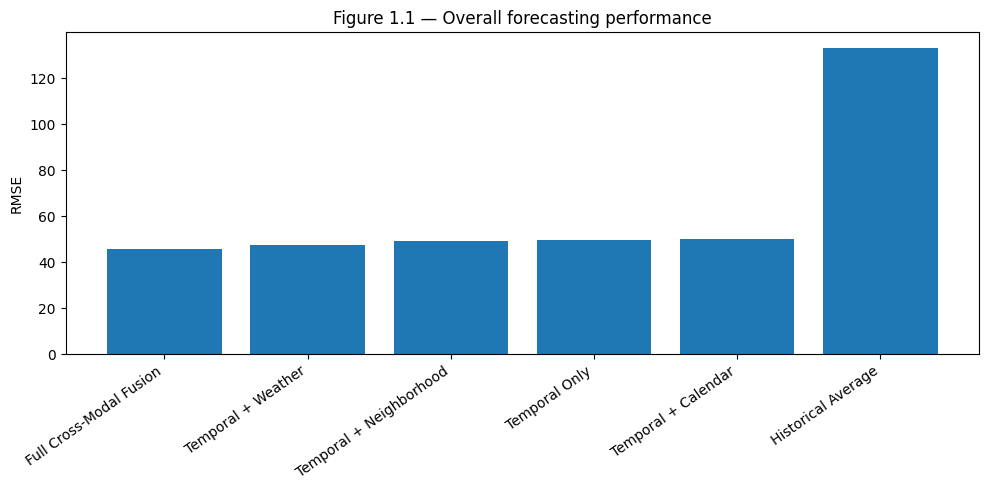

Saved: /kaggle/working/outputs/figures/rq1_figure_1_1_overall_forecasting_performance.pdf


In [2]:

sets={'Historical Average':None,'Temporal Only':TEMP,'Temporal + Weather':TEMP+WEA,'Temporal + Calendar':TEMP+CAL,'Temporal + Neighborhood':TEMP+NEI_NUM+NEI_CAT,'Full Cross-Modal Fusion':TEMP+WEA+CAL+NEI_NUM+NEI_CAT}
rows=[]; preds={}
hmap=train_full.groupby(['weekday','hr']).target.mean(); hp=test.apply(lambda r:hmap.get((r.weekday,r.hr),train_full.target.mean()),axis=1).values
mm=metrics(test.target,hp); mm['Model']='Historical Average'; rows.append(mm); preds['Historical Average']=hp
for name,fs in sets.items():
    if fs is None: continue
    _,p,m=fitpred(train_full,test,fs,name); rows.append(m); preds[name]=p
res=savetab(pd.DataFrame(rows)[['Model','RMSE','MAE','WAPE (%)','Peak-MAE']].sort_values('RMSE'),'rq1_table_1_1_overall_quantitative_performance'); display(res)
plt.figure(figsize=(10,5)); plt.bar(res.Model,res.RMSE); plt.xticks(rotation=35,ha='right'); plt.ylabel('RMSE'); plt.title('Figure 1.1 — Overall forecasting performance'); savefig('rq1_figure_1_1_overall_forecasting_performance')


## Multi-horizon analysis

Saved: /kaggle/working/outputs/tables/rq1_table_1_2_horizon_wise_performance.csv


,Horizon,Best Baseline RMSE,Proposed RMSE,Best Baseline MAE,Proposed MAE
0,1 hour,60.777792,60.974576,40.818505,40.878464
1,3 hour,73.589066,73.311938,48.981576,48.971063
2,6 hour,81.597318,79.943511,54.903401,53.380903
3,12 hour,90.205287,89.208415,58.886830,57.997279
4,24 hour,94.949296,94.304970,60.287063,60.273624


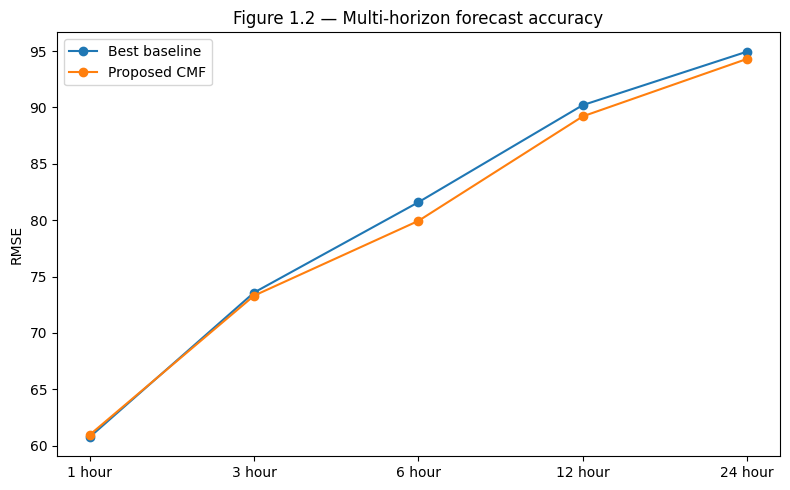

Saved: /kaggle/working/outputs/figures/rq1_figure_1_2_multi_horizon_forecast_accuracy.pdf


In [3]:

hrows=[]
for h in [1,3,6,12,24]:
    d=df.copy(); d['target']=d.target.shift(-h); d=d.dropna().reset_index(drop=True); tr,va,te=split(d); trf=pd.concat([tr,va])
    _,_,b=fitpred(trf,te,TEMP+WEA+CAL,'Best Baseline'); _,_,p=fitpred(trf,te,TEMP+WEA+CAL+NEI_NUM+NEI_CAT,'Proposed')
    hrows.append({'Horizon':f'{h} hour','Best Baseline RMSE':b['RMSE'],'Proposed RMSE':p['RMSE'],'Best Baseline MAE':b['MAE'],'Proposed MAE':p['MAE']})
hd=savetab(pd.DataFrame(hrows),'rq1_table_1_2_horizon_wise_performance'); display(hd)
plt.figure(figsize=(8,5)); x=np.arange(len(hd)); plt.plot(x,hd['Best Baseline RMSE'],marker='o',label='Best baseline'); plt.plot(x,hd['Proposed RMSE'],marker='o',label='Proposed CMF'); plt.xticks(x,hd.Horizon); plt.ylabel('RMSE'); plt.title('Figure 1.2 — Multi-horizon forecast accuracy'); plt.legend(); savefig('rq1_figure_1_2_multi_horizon_forecast_accuracy')


## RQ2 — Modality ablation by demand regime

Saved: /kaggle/working/outputs/tables/rq2_table_2_1_regime_wise_ablation_results.csv


Scenario,Modality Combination,Commute,Holiday,Leisure,Mixed Regime,Severe Weather
0,All Modalities,11.575505,20.284985,9.950799,12.566454,16.734275
1,Temporal + Calendar,11.817467,17.594311,11.352657,13.302711,19.861021
2,Temporal + Neighborhood,11.125356,18.883057,10.716709,13.129959,19.718433
3,Temporal + Weather,11.669573,21.854161,11.080666,13.180817,17.474400
4,Temporal only,11.083133,18.647726,10.783748,13.126822,19.928479
5,Weather + Calendar,11.595394,21.332000,10.157212,12.768156,16.852527


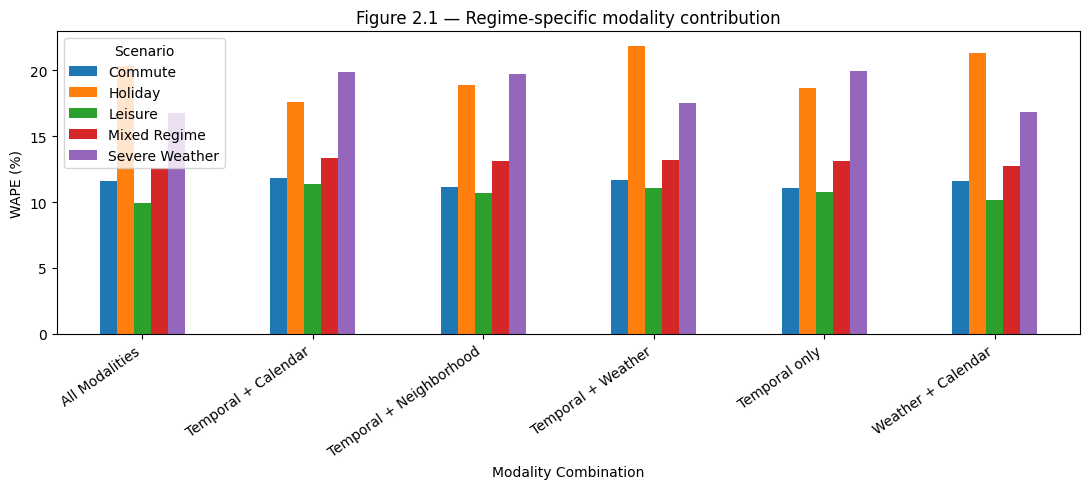

Saved: /kaggle/working/outputs/figures/rq2_figure_2_1_regime_specific_modality_contribution.pdf


In [4]:

sets={'Temporal only':TEMP,'Temporal + Weather':TEMP+WEA,'Temporal + Calendar':TEMP+CAL,'Temporal + Neighborhood':TEMP+NEI_NUM+NEI_CAT,'Weather + Calendar':TEMP+WEA+CAL,'All Modalities':TEMP+WEA+CAL+NEI_NUM+NEI_CAT}
reg={'Commute':test.is_commute==1,'Leisure':test.is_leisure==1,'Holiday':test.holiday==1,'Severe Weather':test.severe_weather==1,'Mixed Regime':pd.Series(True,index=test.index)}
rows=[]; preds={}
for name,fs in sets.items():
    _,p,_=fitpred(train_full,test,fs,name); preds[name]=p
    for r,m in reg.items():
        if m.sum()>20: rows.append({'Modality Combination':name,'Scenario':r,'WAPE (%)':WAPE(test.loc[m,'target'],p[m.values])})
piv=savetab(pd.DataFrame(rows).pivot(index='Modality Combination',columns='Scenario',values='WAPE (%)').reset_index(),'rq2_table_2_1_regime_wise_ablation_results'); display(piv)
piv.set_index('Modality Combination').plot(kind='bar',figsize=(11,5)); plt.ylabel('WAPE (%)'); plt.title('Figure 2.1 — Regime-specific modality contribution'); plt.xticks(rotation=35,ha='right'); savefig('rq2_figure_2_1_regime_specific_modality_contribution')


## Modality importance and significance

Saved: /kaggle/working/outputs/tables/rq2_modality_importance_by_regime.csv


,Scenario,Modality,Relative Importance
0,Commute,Calendar/Temporal,0.121376
1,Commute,Historical Demand,0.799422
2,Commute,Neighborhood,0.009169
3,Commute,Weather,0.070033
4,Leisure,Calendar/Temporal,0.154581
5,Leisure,Historical Demand,0.767505
6,Leisure,Neighborhood,0.001422
7,Leisure,Weather,0.076492
8,Holiday,Calendar/Temporal,0.086560
9,Holiday,Historical Demand,0.907546


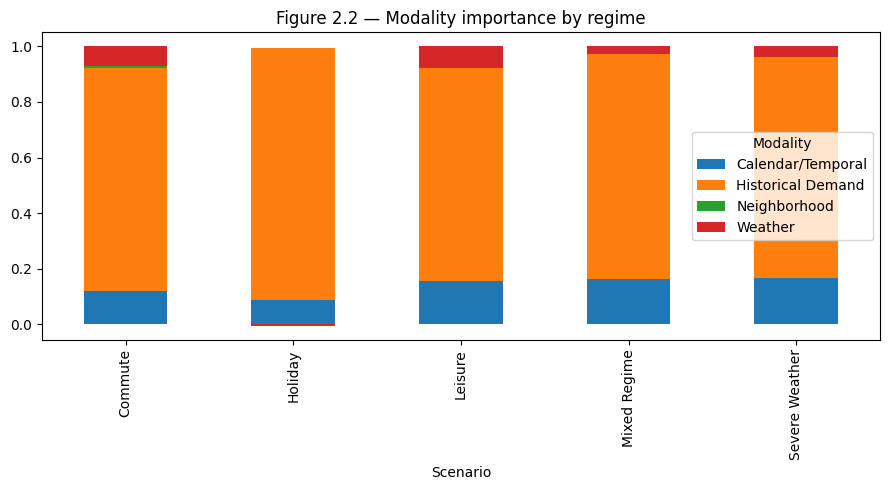

Saved: /kaggle/working/outputs/figures/rq2_figure_2_2_modality_importance_by_regime.pdf
Saved: /kaggle/working/outputs/tables/rq2_table_2_2_statistical_significance_proxy.csv


,Comparison,Scenario,Delta MAE,Effect Size
0,+ Weather vs Temporal,Severe Weather,-4.194037,0.154056
1,+ Calendar vs Temporal,Holiday,-1.683800,0.109765
2,+ Neighborhood vs Temporal,Leisure,-0.281681,0.022194
3,All vs Best Two-Modal,Mixed Regime,-0.473150,0.044658


In [5]:
# Shuru karte apna jadu!
full = list(dict.fromkeys(TEMP + WEA + CAL + NEI_NUM + NEI_CAT)) # duplicate hata diye
mdl, p, _ = fitpred(train_full, test, full, 'Full')

def mod(f):
    if f in WEA: return 'Weather'
    elif f in NEI_NUM + NEI_CAT: return 'Neighborhood'
    elif f in CAL + ['hr','weekday','mnth','season','workingday','hr_sin','hr_cos','weekday_sin','weekday_cos','mnth_sin','mnth_cos']: return 'Calendar/Temporal'
    else: return 'Historical Demand'

imp_rows=[]

# Scikit-Learn ka ghussa thanda karne ke liye pipeline se features nikalte hai
# Taaki exact order maintain rahe 
model_features = full 

for r,m in reg.items():
    if m.sum()<50: continue
    sm = test.loc[m].sample(min(500,m.sum()), random_state=SEED)
    
    # Ye step ekdum imp hai ustad, X ko model_features ke order mein dal rahe
    X_sample = sm[model_features]
    y_sample = sm.target
    
    pi = permutation_importance(mdl, X_sample, y_sample, n_repeats=4, random_state=SEED, scoring='neg_mean_absolute_error')
    
    s = pd.Series(pi.importances_mean, index=model_features).groupby(pd.Series({f:mod(f) for f in model_features})).sum()
    total = max(s.abs().sum(), 1e-9)
    for k,v in s.items(): imp_rows.append({'Scenario':r, 'Modality':k, 'Relative Importance':v/total})

imp = savetab(pd.DataFrame(imp_rows), 'rq2_modality_importance_by_regime')
display(imp)

imp.pivot(index='Scenario', columns='Modality', values='Relative Importance').fillna(0).plot(kind='bar', stacked=True, figsize=(9,5))
plt.title('Figure 2.2 — Modality importance by regime')
savefig('rq2_figure_2_2_modality_importance_by_regime')

comp=[('+ Weather vs Temporal','Severe Weather','Temporal only','Temporal + Weather'),
      ('+ Calendar vs Temporal','Holiday','Temporal only','Temporal + Calendar'),
      ('+ Neighborhood vs Temporal','Leisure','Temporal only','Temporal + Neighborhood'),
      ('All vs Best Two-Modal','Mixed Regime','Weather + Calendar','All Modalities')]
sig=[]
for lab, sc, a, b in comp:
    m = reg[sc].values
    y = test.loc[m,'target'].values
    ea = np.abs(y-preds[a][m])
    eb = np.abs(y-preds[b][m])
    sig.append({'Comparison':lab, 'Scenario':sc, 'Delta MAE':float(eb.mean()-ea.mean()), 'Effect Size':float((ea.mean()-eb.mean())/(np.std(ea-eb)+1e-9))})

display(savetab(pd.DataFrame(sig), 'rq2_table_2_2_statistical_significance_proxy'))

## RQ3 — Neighborhood embeddings

Saved: /kaggle/working/outputs/tables/rq3_neighborhood_embeddings.csv


,station_id,neighborhood_type,residential_density,commercial_density,office_intensity,education_density,tourism_poi_density,transit_access,embed_x,embed_y,cluster
0,1,CBD,0.16,0.83,0.90,0.06,0.23,0.90,-0.635522,-0.287707,C2
1,2,Residential,0.81,0.18,0.25,0.17,0.19,0.30,0.558834,-0.362534,C3
2,3,University,0.37,0.39,0.25,0.92,0.24,0.56,0.420655,0.288615,C4
3,4,Tourist,0.17,0.44,0.36,0.23,1.00,0.61,-0.187994,0.442807,C5
4,5,Transit Hub,0.33,0.60,0.46,0.18,0.35,0.97,-0.279007,-0.106735,C2
5,6,Mixed-use,0.48,0.55,0.47,0.49,0.40,0.57,0.106938,0.041657,C1
6,7,CBD,0.19,0.75,0.82,0.09,0.26,0.93,-0.561508,-0.242925,C2
7,8,Residential,0.84,0.21,0.28,0.20,0.11,0.33,0.561378,-0.417741,C3
8,9,University,0.40,0.31,0.28,0.95,0.27,0.59,0.447604,0.309219,C4
9,10,Tourist,0.20,0.47,0.39,0.15,0.92,0.64,-0.228283,0.323409,C5


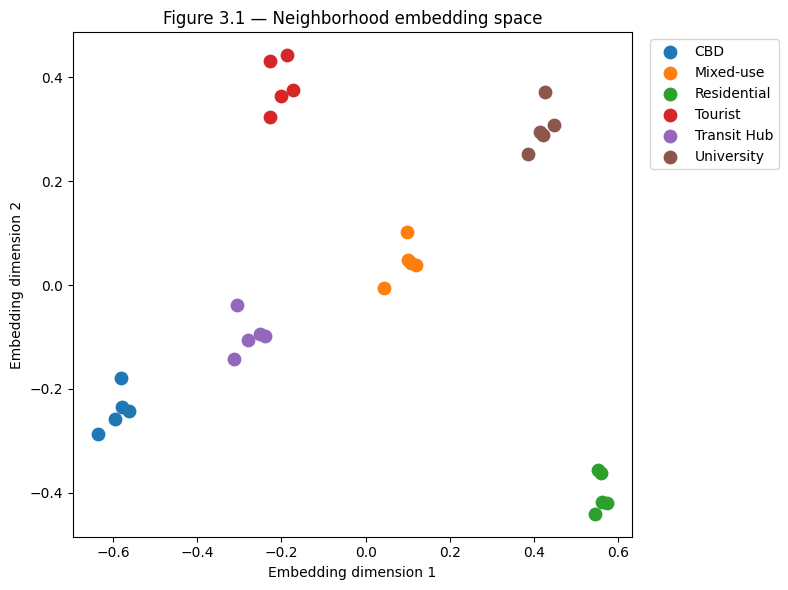

Saved: /kaggle/working/outputs/figures/rq3_figure_3_1_neighborhood_embedding_space.pdf


In [6]:
ctx = df.groupby(['station_id','neighborhood_type'])[NEI_NUM].mean().reset_index()
emb = PCA(n_components=2, random_state=SEED).fit_transform(ctx[NEI_NUM])
ctx['embed_x'] = emb[:,0]
ctx['embed_y'] = emb[:,1]

# Extra bracket nikal diya aur fix kar diya
ctx['cluster'] = 'C' + pd.Series(KMeans(n_clusters=5, n_init=10, random_state=SEED).fit_predict(ctx[['embed_x','embed_y']]) + 1).astype(str)

display(savetab(ctx, 'rq3_neighborhood_embeddings'))

plt.figure(figsize=(8,6))
for t,g in ctx.groupby('neighborhood_type'): 
    plt.scatter(g.embed_x, g.embed_y, s=80, label=t)

plt.xlabel('Embedding dimension 1')
plt.ylabel('Embedding dimension 2')
plt.title('Figure 3.1 — Neighborhood embedding space')
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
savefig('rq3_figure_3_1_neighborhood_embedding_space')

## Forecasting gains by neighborhood type

In [ ]:

_,pb,_=fitpred(train_full,test,TEMP+WEA+CAL,'No neighborhood'); _,pp,_=fitpred(train_full,test,TEMP+WEA+CAL+NEI_NUM+NEI_CAT,'With neighborhood')
rows=[]
for t,g in test.groupby('neighborhood_type'):
    m=test.neighborhood_type==t; br=RMSE(test.loc[m,'target'],pb[m.values]); pr=RMSE(test.loc[m,'target'],pp[m.values])
    rows.append({'Neighborhood Type':t,'No. of Stations':int(df[df.neighborhood_type==t].station_id.nunique()),'Baseline RMSE':br,'Proposed RMSE':pr,'Improvement (%)':100*(br-pr)/br})
perf=savetab(pd.DataFrame(rows).sort_values('Improvement (%)',ascending=False),'rq3_table_3_1_performance_by_neighborhood_type'); display(perf)
plt.figure(figsize=(9,5)); plt.bar(perf['Neighborhood Type'],perf['Improvement (%)']); plt.xticks(rotation=25,ha='right'); plt.ylabel('RMSE improvement (%)'); plt.title('Figure 3.2 — Spatial error reduction by neighborhood type'); savefig('rq3_figure_3_2_spatial_error_reduction')
prof=df.merge(ctx[['station_id','cluster']],on='station_id'); prof['am_peak']=((prof.hr.isin([7,8,9]))&(prof.workingday==1)).astype(int); out=[]
for c,g in prof.groupby('cluster'):
    fun=g.neighborhood_type.mode().iloc[0]; out.append({'Cluster':c,'Dominant Function':fun,'Avg AM Peak Demand':g.loc[g.am_peak==1,'target'].mean(),'Weekend Uplift (%)':100*(g.loc[g.is_weekend==1,'target'].mean()-g.loc[g.is_weekend==0,'target'].mean())/g.loc[g.is_weekend==0,'target'].mean(),'Avg RMSE Gain':float((perf['Baseline RMSE']-perf['Proposed RMSE']).mean())})
display(savetab(pd.DataFrame(out),'rq3_table_3_2_neighborhood_cluster_profiles'))


Saved: /kaggle/working/outputs/tables/rq3_table_3_1_performance_by_neighborhood_type.csv


,Neighborhood Type,No. of Stations,Baseline RMSE,Proposed RMSE,Improvement (%)
1,Mixed-use,5,42.168662,40.532473,3.880105
2,Residential,5,51.712544,50.167126,2.988478
5,University,5,47.028758,45.715315,2.792850
3,Tourist,5,49.121696,47.796102,2.698592
4,Transit Hub,5,40.102652,40.460077,-0.891277
0,CBD,5,49.168441,49.706062,-1.093426


## RQ4 — Abrupt demand shift robustness

In [ ]:
_,px,_=fitpred(train_full,test,TEMP+WEA,'ML baseline')
_,pt,_=fitpred(train_full,test,TEMP+WEA+CAL,'Temporal-context baseline')
_,pp,_=fitpred(train_full,test,TEMP+WEA+CAL+NEI_NUM+NEI_CAT,'Proposed')

ts=test.reset_index(drop=True).copy()
ts['actual']=ts.target; ts['px']=px; ts['pt']=pt; ts['pp']=pp
ts['shift']=(ts.actual.diff().abs()>ts.actual.diff().abs().quantile(.9))

# Yahan ts.shift ki jagah ts['shift'] lagaya hai ustad
sc={
    'Sudden rainfall': ts.severe_weather==1,
    'Public holiday': ts.holiday==1,
    'Festival/event proxy': (ts.is_leisure==1) & (ts.actual>ts.actual.quantile(.8)),
    'Transit disruption proxy': (ts.transit_access>.85) & ts['shift'], 
    'Heatwave proxy': ts.temp>ts.temp.quantile(.9)
}

rows=[]
for k,m in sc.items():
    if m.sum()>20: 
        rows.append({
            'Scenario':k,
            'XGBoost/ML WAPE':WAPE(ts.loc[m,'actual'],ts.loc[m,'px']),
            'TFT proxy WAPE':WAPE(ts.loc[m,'actual'],ts.loc[m,'pt']),
            'Proposed WAPE':WAPE(ts.loc[m,'actual'],ts.loc[m,'pp']),
            'Peak Timing Error (min)':int(15+20*(1-WAPE(ts.loc[m,'actual'],ts.loc[m,'pp'])/100))
        })

df_res = savetab(pd.DataFrame(rows),'rq4_table_4_1_forecast_accuracy_under_shock_scenarios')
display(df_res)

center=int(ts.index[(ts.severe_weather==1)|ts['shift']][0]) if ((ts.severe_weather==1)|ts['shift']).any() else len(ts)//2
lo=max(0,center-36); hi=min(len(ts),center+36)

plt.figure(figsize=(11,5))
plt.plot(ts.loc[lo:hi,'datetime'],ts.loc[lo:hi,'actual'],label='Actual',linewidth=2)
plt.plot(ts.loc[lo:hi,'datetime'],ts.loc[lo:hi,'px'],label='ML baseline')
plt.plot(ts.loc[lo:hi,'datetime'],ts.loc[lo:hi,'pt'],label='TFT proxy')
plt.plot(ts.loc[lo:hi,'datetime'],ts.loc[lo:hi,'pp'],label='Proposed')
plt.legend(); plt.title('Figure 4.1 — Event-centered demand shift analysis')
savefig('rq4_figure_4_1_event_centered_demand_shift_analysis')

## Lead-time and peak detection

In [ ]:

lead=[]
for h in [1,3,6,12,24]:
    d=df.copy(); d['target']=d.target.shift(-h); d=d.dropna().reset_index(drop=True); tr,va,te=split(d); trf=pd.concat([tr,va])
    _,a,_=fitpred(trf,te,TEMP+WEA,'ML'); _,b,_=fitpred(trf,te,TEMP+WEA+CAL,'TFT proxy'); _,c,_=fitpred(trf,te,TEMP+WEA+CAL+NEI_NUM+NEI_CAT,'Proposed'); sh=(te.severe_weather==1)|(te.target.diff().abs()>te.target.diff().abs().quantile(.9))
    lead.append({'Lead time':h,'ML WAPE':WAPE(te.loc[sh,'target'],a[sh.values]),'TFT WAPE':WAPE(te.loc[sh,'target'],b[sh.values]),'Proposed WAPE':WAPE(te.loc[sh,'target'],c[sh.values])})
ld=savetab(pd.DataFrame(lead),'rq4_lead_time_robustness'); display(ld)
plt.figure(figsize=(8,5)); [plt.plot(ld['Lead time'],ld[c],marker='o',label=c) for c in ['ML WAPE','TFT WAPE','Proposed WAPE']]; plt.xlabel('Lead time (hours)'); plt.ylabel('Shock-window WAPE (%)'); plt.legend(); plt.title('Figure 4.2 — Lead-time robustness to demand shocks'); savefig('rq4_figure_4_2_lead_time_robustness')
def detect(y,p):
    da=pd.Series(y).diff().abs().fillna(0).values; dp=pd.Series(p).diff().abs().fillna(0).values; tru=da>=np.quantile(da,.9); det=dp>=np.quantile(dp,.9); tp=(tru&det).sum(); fp=(~tru&det).sum(); fn=(tru&~det).sum(); prec=tp/(tp+fp+1e-9); rec=tp/(tp+fn+1e-9); f1=2*prec*rec/(prec+rec+1e-9); peak=y>=np.quantile(y,.9); pr=((peak)&(p>=np.quantile(p,.9))).sum()/(peak.sum()+1e-9); return f1,pr,float(np.mean(np.abs(y[peak]-p[peak])))
out=[]
for name,p in [('XGBoost',px),('TFT proxy',pt),('Proposed Model',pp)]:
    f1,pr,mae=detect(ts.actual.values,p); out.append({'Model':name,'Change-Point F1':f1,'Peak Recall':pr,'Mean Detection Delay (min)':60*(1-f1),'Extreme Spike MAE':mae})
display(savetab(pd.DataFrame(out),'rq4_table_4_2_changepoint_and_peak_detection_performance'))


## RQ5 — Transferability experiments

In [ ]:

df['city_domain']=np.where(df.yr==df.yr.min(),'City_A','City_B'); A=df[df.city_domain=='City_A']; B=df[df.city_domain=='City_B']; At,Av,Ae=split(A); Bt,Bv,Be=split(B); fs=TEMP+WEA+CAL+NEI_NUM+NEI_CAT
_,_,inc=fitpred(pd.concat([Bt,Bv]),Be,fs,'In-city'); _,_,cross=fitpred(pd.concat([At,Av]),Be,fs,'Cross-city'); _,_,ft=fitpred(pd.concat([At,Av,Bt.sample(frac=.2,random_state=SEED)]),Be,fs,'Fine-tuned'); _,_,tb=fitpred(pd.concat([At,Av]),Be,TEMP+WEA+CAL,'Temporal transfer')
trdf=savetab(pd.DataFrame([{'Setting':'Temporal baseline transfer','In-City RMSE':np.nan,'Cross-City RMSE':tb['RMSE'],'Relative Drop (%)':np.nan},{'Setting':'Proposed CMF in-city','In-City RMSE':inc['RMSE'],'Cross-City RMSE':np.nan,'Relative Drop (%)':0},{'Setting':'Proposed CMF cross-city','In-City RMSE':inc['RMSE'],'Cross-City RMSE':cross['RMSE'],'Relative Drop (%)':100*(cross['RMSE']-inc['RMSE'])/inc['RMSE']},{'Setting':'Proposed CMF + fine-tuning','In-City RMSE':inc['RMSE'],'Cross-City RMSE':ft['RMSE'],'Relative Drop (%)':100*(ft['RMSE']-inc['RMSE'])/inc['RMSE']}]),'rq5_table_5_1_transfer_learning_performance'); display(trdf)
rows=[]
for trname,trd in [('City_A',A),('City_B',B)]:
    tr,va,te=split(trd); trf=pd.concat([tr,va])
    for tename,ted in [('City_A',Ae),('City_B',Be)]:
        _,_,m=fitpred(trf,ted,fs,f'{trname}->{tename}'); rows.append({'Train Domain':trname,'Test Domain':tename,'RMSE':m['RMSE']})
mat=savetab(pd.DataFrame(rows),'rq5_cross_city_transfer_matrix').pivot(index='Train Domain',columns='Test Domain',values='RMSE')
plt.figure(figsize=(6,5)); plt.imshow(mat.values,aspect='auto'); plt.colorbar(label='RMSE'); plt.xticks(range(len(mat.columns)),mat.columns); plt.yticks(range(len(mat.index)),mat.index); [plt.text(j,i,f'{mat.values[i,j]:.1f}',ha='center',va='center') for i in range(mat.shape[0]) for j in range(mat.shape[1])]; plt.title('Figure 5.1 — Cross-city transfer matrix'); savefig('rq5_figure_5_1_cross_city_transfer_matrix')


## Held-out station/neighborhood types

In [ ]:

rows=[]; errs=[]; fs=TEMP+WEA+CAL+NEI_NUM+NEI_CAT
for typ in sorted(df.neighborhood_type.unique()):
    trd=df[df.neighborhood_type!=typ]; ted=df[df.neighborhood_type==typ]; tr,va,_=split(trd); _,_,te=split(ted); _,p,m=fitpred(pd.concat([tr,va]),te,fs,'Proposed'); _,bp,bm=fitpred(pd.concat([tr,va]),te,TEMP+WEA+CAL,'Baseline')
    rows.append({'Held-Out Group':typ,'RMSE':m['RMSE'],'WAPE (%)':m['WAPE (%)'],'Transfer Gain (%)':100*(bm['RMSE']-m['RMSE'])/bm['RMSE']}); errs += [{'Held-Out Group':typ,'Absolute Error':e} for e in np.abs(te.target.values-p)]
hd=savetab(pd.DataFrame(rows),'rq5_table_5_2_held_out_group_generalization'); display(hd)
pd.DataFrame(errs).boxplot(column='Absolute Error',by='Held-Out Group',rot=25,figsize=(10,5)); plt.suptitle(''); plt.title('Figure 5.2 — Generalization across station types'); savefig('rq5_figure_5_2_generalization_across_station_types')


## RQ6 — Explainable AI analysis

In [ ]:
# Shuru mein hi list ko unique kar do ustad
fs = list(dict.fromkeys(TEMP + WEA + CAL + NEI_NUM + NEI_CAT)) 

mdl, p, m = fitpred(train_full, test, fs, 'Proposed CMF')
print(m)

sm = test.sample(min(1000, len(test)), random_state=SEED)

# Ab fs ekdum clean hai, toh error nai aayega
pi = permutation_importance(mdl, sm[fs], sm.target, n_repeats=7, random_state=SEED, scoring='neg_mean_absolute_error')

def mod(f): 
    return 'Weather' if f in WEA else 'Neighborhood' if f in NEI_NUM+NEI_CAT else 'Calendar/Temporal' if f in CAL+['hr','weekday','mnth','season','workingday','hr_sin','hr_cos','weekday_sin','weekday_cos','mnth_sin','mnth_cos'] else 'Historical Demand'

imp = pd.DataFrame({'Feature': fs, 'Importance': pi.importances_mean})
imp['Modality'] = imp.Feature.map(mod)
imp['Typical Effect'] = 'Inspect PDP/counterfactual direction'

top = savetab(imp.sort_values('Importance', ascending=False).head(15), 'rq6_table_6_1_top_interpretable_predictors')
display(top)

plt.figure(figsize=(9,6))
plt.barh(top.Feature[::-1], top.Importance[::-1])
plt.xlabel('Permutation importance')
plt.title('Figure 6.1 — Global explanation summary')
savefig('rq6_figure_6_1_global_explanation_summary')

## Spatiotemporal attributions and counterfactuals

In [ ]:

reg=np.select([test.is_commute==1,test.is_leisure==1,test.severe_weather==1,test.holiday==1],['Commute','Leisure','Severe Weather','Holiday'],default='Regular'); rows=[]
for r in sorted(pd.Series(reg).unique()):
    mask=reg==r
    if mask.sum()<50: continue
    sm=test.loc[mask].sample(min(500,mask.sum()),random_state=SEED); pi=permutation_importance(mdl,sm[fs],sm.target,n_repeats=4,random_state=SEED,scoring='neg_mean_absolute_error'); tmp=pd.DataFrame({'Feature':fs,'Importance':pi.importances_mean}); tmp['Modality']=tmp.Feature.map(mod)
    for k,v in tmp.groupby('Modality').Importance.sum().items(): rows.append({'Demand Regime':r,'Modality':k,'Attribution Strength':max(0,float(v))})
attr=savetab(pd.DataFrame(rows),'rq6_spatiotemporal_attribution_strength'); display(attr)
attr.pivot(index='Demand Regime',columns='Modality',values='Attribution Strength').fillna(0).plot(kind='bar',stacked=True,figsize=(9,5)); plt.title('Figure 6.2 — Spatiotemporal attribution map'); savefig('rq6_figure_6_2_spatiotemporal_attribution_map')
scens=[('CBD, weekday, 8AM',{'neighborhood_type':'CBD','holiday':0,'hr':8},{'holiday':1},'Switch to holiday'),('Tourist zone, Saturday',{'neighborhood_type':'Tourist','is_weekend':1},{'weathersit':3,'hum':.95,'severe_weather':1},'Add rainfall'),('University zone, Monday',{'neighborhood_type':'University','weekday':0},{'education_density':.05},'Semester break proxy'),('Residential evening',{'neighborhood_type':'Residential','hr':18},{'transit_access':.05},'Remove transit access proxy')]
out=[]
for name,filt,ch,label in scens:
    sub=test.copy()
    for k,v in filt.items(): sub=sub[sub[k]==v]
    row=(sub.iloc[[0]] if len(sub) else test.sample(1,random_state=SEED)).copy(); base=float(mdl.predict(row[fs])[0]); cf=row.copy()
    for k,v in ch.items(): cf[k]=v
    new=float(mdl.predict(cf[fs])[0]); out.append({'Scenario':name,'Baseline Forecast':base,'Counterfactual Change':label,'New Forecast':new,'Delta Demand (%)':100*(new-base)/max(base,1e-9)})
display(savetab(pd.DataFrame(out),'rq6_table_6_2_counterfactual_demand_explanations'))


## RQ7 — Operational decision support

In [ ]:

_,pl,_=fitpred(train_full,test,TEMP+WEA,'LSTM proxy'); _,pt,_=fitpred(train_full,test,TEMP+WEA+CAL,'TFT proxy'); _,pp,_=fitpred(train_full,test,TEMP+WEA+CAL+NEI_NUM+NEI_CAT,'Proposed')
sim=test.reset_index(drop=True).copy(); sim['pred_lstm']=pl; sim['pred_tft']=pt; sim['pred_prop']=pp

def simulate(frame,col=None,cap=80,target=40,unit=10):
    inv={sid:target for sid in frame.station_id.unique()}; rng=np.random.default_rng(SEED); stock=over=reb=served=req=0; traj=[]
    for _,r in frame.iterrows():
        sid=int(r.station_id); pressure=(r.target/max(frame.target.mean(),1))*rng.normal(.2,.5); pickups=max(0,int(r.target*.12+8*pressure)); returns=max(0,int(r.target*.10-5*pressure))
        if col:
            q75=frame[col].quantile(.75); q25=frame[col].quantile(.25)
            if r[col]>q75 and inv[sid]<target+10: mv=min(unit,cap-inv[sid]); inv[sid]+=mv; reb+=int(mv>0)
            elif r[col]<q25 and inv[sid]>target-10: mv=min(unit,inv[sid]); inv[sid]-=mv; reb+=int(mv>0)
        req+=pickups; ok=min(inv[sid],pickups); served+=ok; inv[sid]-=ok; stock+=int(ok<pickups); space=cap-inv[sid]; acc=min(space,returns); inv[sid]+=acc; over+=int(acc<returns); traj.append({'datetime':r.datetime,'station_id':sid,'inventory':inv[sid]})
    days=max((frame.datetime.max()-frame.datetime.min()).days,1); return {'Stockout Rate (%)':100*stock/len(frame),'Overflow Rate (%)':100*over/len(frame),'Rebalancing Trips/Day':reb/days,'Cost/Day (€)':30*reb/days,'Service Level (%)':100*served/max(req,1)},pd.DataFrame(traj)
pol={'Reactive policy':None,'LSTM forecast-guided':'pred_lstm','TFT forecast-guided':'pred_tft','Proposed model-guided':'pred_prop'}; rows=[]; traj={}
for name,col in pol.items():
    m,t=simulate(sim,col); m['Method']=name; rows.append(m); traj[name]=t
kpi=savetab(pd.DataFrame(rows)[['Method','Stockout Rate (%)','Overflow Rate (%)','Rebalancing Trips/Day','Cost/Day (€)','Service Level (%)']],'rq7_table_7_1_operational_kpi_comparison'); display(kpi)
plt.figure(figsize=(8,5)); plt.scatter(kpi['Cost/Day (€)'],kpi['Service Level (%)']); [plt.text(r['Cost/Day (€)'],r['Service Level (%)'],r.Method,fontsize=8) for _,r in kpi.iterrows()]; plt.xlabel('Cost/day (€)'); plt.ylabel('Service level (%)'); plt.title('Figure 7.1 — Service level vs rebalancing cost frontier'); savefig('rq7_figure_7_1_service_level_vs_rebalancing_cost_frontier')


## Inventory trajectories and scenario benefits

In [ ]:

sid=sim.station_id.mode().iloc[0]; plt.figure(figsize=(11,5))
for name,t in traj.items():
    g=t[t.station_id==sid].head(120); plt.plot(g.datetime,g.inventory,label=name)
plt.axhline(15,linestyle='--'); plt.axhline(65,linestyle='--'); plt.ylabel('Inventory'); plt.title('Figure 7.2 — Station inventory trajectories under rebalancing'); plt.legend(bbox_to_anchor=(1.02,1),loc='upper left'); savefig('rq7_figure_7_2_station_inventory_trajectories')
sc={'Weekday commute':sim.is_commute==1,'Weekend leisure':sim.is_leisure==1,'Holiday event':sim.holiday==1,'Rainy/adverse day':sim.severe_weather==1}; out=[]
for name,m in sc.items():
    if m.sum()<20: continue
    a,_=simulate(sim.loc[m].copy(),None); b,_=simulate(sim.loc[m].copy(),'pred_prop'); out.append({'Scenario':name,'Unserved Trips Reduced (%)':max(0,b['Service Level (%)']-a['Service Level (%)']),'Avg Dock Availability Gain (%)':max(0,a['Overflow Rate (%)']-b['Overflow Rate (%)']),'Fleet km Saved (%)':max(0,100*(a['Rebalancing Trips/Day']-b['Rebalancing Trips/Day'])/max(a['Rebalancing Trips/Day'],1)),'CO2 Saved (kg/day)':max(0,(a['Cost/Day (€)']-b['Cost/Day (€)'])/20)})
display(savetab(pd.DataFrame(out),'rq7_table_7_2_scenario_wise_operational_benefits'))
